In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import numpy as np
from stable_baselines3.common.env_checker import check_env

# Sequential DDA environment test

In [4]:
from vimms.Common import POSITIVE
from vimms.ChemicalSamplers import MZMLFormulaSampler, MZMLRTandIntensitySampler

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.features import obs_to_dfs

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
 /opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning:hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.


In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (500, 2000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E5, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE
noise_density = 0.3
noise_max_val = 1e4

In [9]:
mzml_filename = 'Beer_multibeers_1_fullscan1.mzML'
mz_sampler = MZMLFormulaSampler(mzml_filename, min_mz=min_mz, max_mz=max_mz)
ri_sampler = MZMLRTandIntensitySampler(mzml_filename, min_rt=min_rt, max_rt=max_rt,
                                       min_log_intensity=min_log_intensity,
                                       max_log_intensity=max_log_intensity)

2022-03-18 14:28:07.130 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans
2022-03-18 14:28:08.993 | DEBUG    | mass_spec_utils.data_import.mzml:_load_file:166 - Loaded 1109 scans


In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
    },
    'noise': {
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'N': N,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
        'min_ms1_intensity': min_ms1_intensity
    }
}

Initialise a new DDA environment that tracks the top-20 most intense peaks.

In [290]:
max_peaks = 10
env = DDAEnv(max_peaks, params)
check_env(env)

Generate an initial observation (MS1 scan) -- can be empty

In [291]:
observation = env.reset()
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

(   intensities  fragmented  excluded
 0          0.0         0.0       0.0
 1          0.0         0.0       0.0
 2          0.0         0.0       0.0
 3          0.0         0.0       0.0
 4          0.0         0.0       0.0
 5          0.0         0.0       0.0
 6          0.0         0.0       0.0
 7          0.0         0.0       0.0
 8          0.0         0.0       0.0
 9          0.0         0.0       0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start        1.0
 elapsed_scans_since_last_ms1     0.0)

In [292]:
observation['valid_actions']

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [293]:
env.features

[]

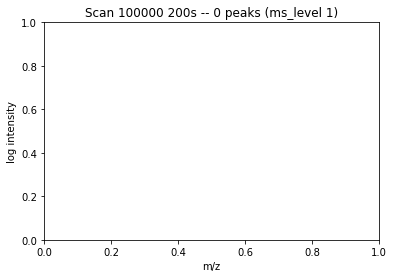

In [294]:
env.render()

Generate 5 ms1 scans

In [295]:
for i in range(5):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded
 0    17.257849         0.0       0.0
 1    16.617868         0.0       0.0
 2     0.000000         0.0       0.0
 3     0.000000         0.0       0.0
 4     0.000000         0.0       0.0
 5     0.000000         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start        6.0
 elapsed_scans_since_last_ms1     0.0)

In [296]:
observation['valid_actions']

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [297]:
env.features

[mz=126.9001434184708 rt=202.00000000000003 intensity=31259986.987903953 (17.257849466703647),
 mz=116.55218450102944 rt=202.00000000000003 intensity=16483465.771857891 (16.617868362025707)]

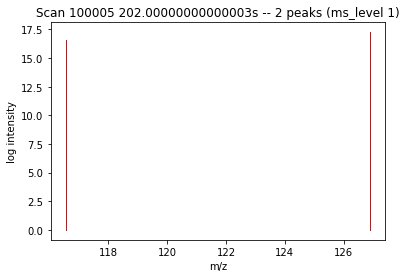

In [298]:
env.render()

Target the most intense precursor for fragmentation, and generate an MS2 scan from that

In [299]:
action = 0
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 1.0
done False


(   intensities  fragmented  excluded
 0    17.257849         1.0       0.4
 1    16.617868         0.0       0.0
 2     0.000000         0.0       0.0
 3     0.000000         0.0       0.0
 4     0.000000         0.0       0.0
 5     0.000000         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 1.0
 unfragmented_count               9.0
 excluded_count                   1.0
 unexcluded_count                 9.0
 elapsed_scans_since_start        7.0
 elapsed_scans_since_last_ms1     1.0)

In [300]:
observation['valid_actions']

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [301]:
env.features

[mz=126.9001434184708 rt=202.00000000000003 intensity=31259986.987903953 (17.257849466703647),
 mz=116.55218450102944 rt=202.00000000000003 intensity=16483465.771857891 (16.617868362025707)]

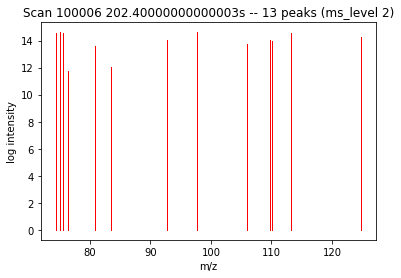

In [302]:
env.render()

Target the next most intense precursor for fragmentation, and generate an MS2 scan

In [303]:
action = 1
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward 1.0
done False


(   intensities  fragmented  excluded
 0    17.257849         1.0       0.6
 1    16.617868         1.0       0.6
 2     0.000000         0.0       0.0
 3     0.000000         0.0       0.0
 4     0.000000         0.0       0.0
 5     0.000000         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 2.0
 unfragmented_count               8.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start        8.0
 elapsed_scans_since_last_ms1     2.0)

In [304]:
observation['valid_actions']

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [305]:
env.features

[mz=126.9001434184708 rt=202.00000000000003 intensity=31259986.987903953 (17.257849466703647),
 mz=116.55218450102944 rt=202.00000000000003 intensity=16483465.771857891 (16.617868362025707)]

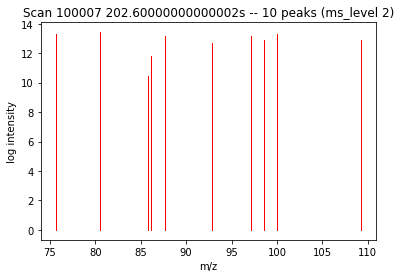

In [306]:
env.render()

Repeat targeting of the same precursor produces negative reward, up to a point

In [307]:
for i in range(10):
    action = 0
    observation, reward, done, info = env.step(action)
    print('reward', reward)
    # print('done', done)
    # pp.pprint(observation)
    # env.render()

reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0
reward -1.0


In [308]:
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

(   intensities  fragmented  excluded
 0    17.257849        11.0       2.6
 1    16.617868         1.0       2.6
 2     0.000000         0.0       0.0
 3     0.000000         0.0       0.0
 4     0.000000         0.0       0.0
 5     0.000000         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         0.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 2.0
 unfragmented_count               8.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start       18.0
 elapsed_scans_since_last_ms1    12.0)

In [309]:
observation['valid_actions']

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [310]:
env.features

[mz=126.9001434184708 rt=202.00000000000003 intensity=31259986.987903953 (17.257849466703647),
 mz=116.55218450102944 rt=202.00000000000003 intensity=16483465.771857891 (16.617868362025707)]

Making an invalid move produces negative reward.

In [311]:
action = 9 # no precursor to fragment at this index
observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -1
done False


(   intensities  fragmented  excluded
 0    17.257849        11.0       2.8
 1    16.617868         1.0       2.8
 2     0.000000         0.0       0.0
 3     0.000000         0.0       0.0
 4     0.000000         0.0       0.0
 5     0.000000         0.0       0.0
 6     0.000000         0.0       0.0
 7     0.000000         0.0       0.0
 8     0.000000         0.0       0.0
 9     0.000000         1.0       0.0,
                               counts
 ms_level                         2.0
 fragmented_count                 3.0
 unfragmented_count               7.0
 excluded_count                   2.0
 unexcluded_count                 8.0
 elapsed_scans_since_start       19.0
 elapsed_scans_since_last_ms1    13.0)

In [312]:
observation['valid_actions']

array([1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [313]:
env.features

[mz=126.9001434184708 rt=202.00000000000003 intensity=31259986.987903953 (17.257849466703647),
 mz=116.55218450102944 rt=202.00000000000003 intensity=16483465.771857891 (16.617868362025707)]

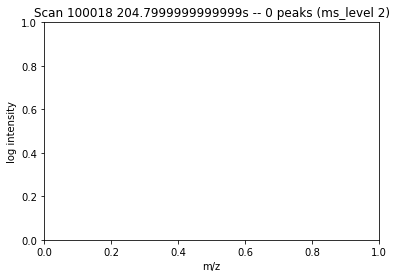

In [314]:
env.render()

Generate lots of MS1 scans

In [315]:
for i in range(100):
    action = max_peaks # ms1
    observation, reward, done, info = env.step(action)

print('reward', reward)
print('done', done)
scan_df, count_df = obs_to_dfs(observation)
scan_df, count_df

reward -0.1
done False


(   intensities  fragmented  excluded
 0    22.609795         0.0       0.0
 1    22.086850         0.0       0.0
 2    22.054991         0.0       0.0
 3    21.643087         0.0       0.0
 4    21.633784         0.0       0.0
 5    21.538528         0.0       0.0
 6    21.385741         0.0       0.0
 7    21.054553         0.0       0.0
 8    20.909157         0.0       0.0
 9    20.378546         0.0       0.0,
                               counts
 ms_level                         1.0
 fragmented_count                 0.0
 unfragmented_count              10.0
 excluded_count                   0.0
 unexcluded_count                10.0
 elapsed_scans_since_start      119.0
 elapsed_scans_since_last_ms1     0.0)

In [316]:
observation['valid_actions']

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [317]:
env.features

[mz=157.30023330263427 rt=244.60000000000045 intensity=6596432119.596405 (22.60979475186851),
 mz=252.47985568854753 rt=244.60000000000045 intensity=3910184560.4603243 (22.086850411993463),
 mz=227.9669278607505 rt=244.60000000000045 intensity=3787571625.153236 (22.054990918534635),
 mz=268.2381772081241 rt=244.60000000000045 intensity=2508841743.452307 (21.643087026794245),
 mz=258.5938265390265 rt=244.60000000000045 intensity=2485611296.6993837 (21.63378446089092),
 mz=212.72909216884375 rt=244.60000000000045 intensity=2259768871.1015115 (21.53852837557662),
 mz=115.97392726524589 rt=244.60000000000045 intensity=1939586424.2623577 (21.385740603924926),
 mz=294.3090675851212 rt=244.60000000000045 intensity=1392759606.3089626 (21.05455294420918),
 mz=130.3308741140569 rt=244.60000000000045 intensity=1204291275.26429 (20.90915707755138),
 mz=309.32771345268264 rt=244.60000000000045 intensity=708419150.8774763 (20.378546497496075)]

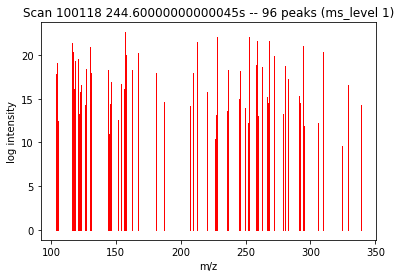

In [318]:
env.render()